In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Preprocessing ===
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# === Models ===
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# === Metrics ===
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)

# === Chuyển đổi 2 cột dạng chữ về giá trị số ===
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# === CONFIG === #
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# === BÀi Toán === #
PROBLEM_TYPE='Classification'
TARGET_COL= 'churn_target'

In [2]:
df = pd.read_csv(r'/Users/thanhnhat/Documents/mock project/Data/churn_data_customer.csv')
print('Số dòng:', len(df))
print('Số cột:', df.shape[1])
print()
print('Danh sách cột:')
print(df.columns)


Số dòng: 50000
Số cột: 24

Danh sách cột:
Index(['customer_id', 'age', 'account_tenure_months', 'monthly_active_days',
       'avg_daily_usage_minutes', 'num_sessions_per_week',
       'support_tickets_30d', 'payment_delay_days', 'subscription_type',
       'has_active_promo', 'app_rating', 'num_notification_opt_out',
       'customer_support_satisfaction', 'monthly_charges', 'churn_target',
       'avg_active_days_3m', 'usage_minutes_3m', 'support_tickets_3m',
       'avg_active_days_6m', 'usage_minutes_6m', 'support_tickets_6m',
       'avg_active_days_12m', 'usage_minutes_12m', 'support_tickets_12m'],
      dtype='str')


---
# Bước 4: Định nghĩa Label / Target 🏷️

- **Biến target**: `TARGET`
- **Ý nghĩa**: 0 = No Churn (Tiếp tục dùng), 1 = Churn (Bỏ app)
- **pos_label** (lớp quan tâm) = **1** (Default) — vì bỏ sót khách, không chăm sóc sẽ gây thiệt hại đến doanh thu

In [3]:
# === TÁCH X, y ===
X = df.drop(columns=[TARGET_COL,'customer_id']) # Bỏ cột customer_id và target_col=churn_rate
y = df[TARGET_COL]




print(f"X shape: {X.shape}  (features)")
print(f"y shape: {y.shape}")
print(f"\ny distribution:")
print(f"  0 (Good): {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")
print(f"  1 (Bad):  {(y==1).sum():,} ({(y==1).mean()*100:.2f}%)")
print(f"\nFeatures ({X.shape[1]}): {X.columns.tolist()}")

X shape: (50000, 22)  (features)
y shape: (50000,)

y distribution:
  0 (Good): 37,881 (75.76%)
  1 (Bad):  12,119 (24.24%)

Features (22): ['age', 'account_tenure_months', 'monthly_active_days', 'avg_daily_usage_minutes', 'num_sessions_per_week', 'support_tickets_30d', 'payment_delay_days', 'subscription_type', 'has_active_promo', 'app_rating', 'num_notification_opt_out', 'customer_support_satisfaction', 'monthly_charges', 'avg_active_days_3m', 'usage_minutes_3m', 'support_tickets_3m', 'avg_active_days_6m', 'usage_minutes_6m', 'support_tickets_6m', 'avg_active_days_12m', 'usage_minutes_12m', 'support_tickets_12m']


---
# Bước 5: Feature Engineering 🔧


In [4]:
# === TẠO FEATURES MỚI (Biến phái sinh)===

# 1. ENGAGEMENT_SCORE - Điểm tương tác tổng hợp (0 đến 1)
# Kết hợp số ngày hoạt động (40%), thời gian dùng (40%) và số phiên truy cập (20%)
X['engagement_score'] = (
    (X['monthly_active_days'] / 30) * 0.4 +
    np.clip(X['avg_daily_usage_minutes'], 0, 120) / 120 * 0.4 +
    np.clip(X['num_sessions_per_week'], 0, 14) / 14 * 0.2
).round(4)

# 2. SATISFACTION_SCORE - Điểm hài lòng tổng hợp (0 đến 1)
# Kết hợp đánh giá app (50%) và hài lòng hỗ trợ khách hàng (50%)
X['satisfaction_score'] = (
    X['app_rating'] / 5 * 0.5 +
    X['customer_support_satisfaction'] / 5 * 0.5
).round(4)

# 3. USAGE_TREND_3M_6M - Xu hướng sử dụng 3 tháng so với 6 tháng
# Giá trị âm nghĩa là đang giảm sử dụng, giá trị dương là đang tăng
X['usage_trend_3m_6m'] = (
    (X['usage_minutes_3m'] - X['usage_minutes_6m']) / (X['usage_minutes_6m'] + 1)
).round(4)

new_features = ['engagement_score', 'satisfaction_score', 'usage_trend_3m_6m']

print('Đã tạo thêm', len(new_features), 'biến phái sinh:')
print()
for f in new_features:
    print(f'  {f}: min={X[f].min():.3f}, max={X[f].max():.3f}, trung bình={X[f].mean():.3f}')

Đã tạo thêm 3 biến phái sinh:

  engagement_score: min=0.044, max=1.000, trung bình=0.573
  satisfaction_score: min=0.200, max=1.000, trung bình=0.762
  usage_trend_3m_6m: min=-0.980, max=63.547, trung bình=0.301


In [5]:
#Endcoding 2 cột là chữ về giá trị số
X['subscription_type_enc'] = LabelEncoder().fit_transform(X['subscription_type'])
X['has_active_promo_enc'] = (X['has_active_promo'] == 'Yes').astype(int)

X=X.drop(columns=['subscription_type','has_active_promo'])
#Kiểm tra dòng và cột
# print(X.shape)
# print(X.columns)
print(X.head(10))

   age  account_tenure_months  monthly_active_days  avg_daily_usage_minutes  \
0   47                     13                   20                56.015159   
1   37                     34                    1                 9.461102   
2   50                      5                   26               157.328391   
3   65                     46                   23                79.827399   
4   37                      2                   20                50.339759   
5   38                     53                   26                72.956660   
6   63                     25                   23                77.587605   
7   51                      2                   25                68.141086   
8   34                      8                   21                58.531299   
9   49                     15                   13                35.378961   

   num_sessions_per_week  support_tickets_30d  payment_delay_days  app_rating  \
0                     11                    1    

---
# Bước 6: Feature Selection 🔍

Loại features không cần thiết: constant, highly correlated

In [6]:
print(f"Số features trước selection: {X.shape[1]}")


# --- 6.2: Loại cột highly correlated (> 0.9) ---
CORR_THRESHOLD = 0.9
corr_matrix = X.corr().abs()

#np.triu(..., k=1) (Triangle Upper): Tạo ra một tấm mặt nạ (mask) khuôn hình tam giác bằng các giá trị True / False. Vạch cắt bắt đầu từ trên đường chéo chính 1 bậc (k=1).
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
print(f"\n Xem cột Upper {high_corr_cols}  - {len(high_corr_cols)} cột")

pd.set_option('display.expand_frame_repr',False)
pd.set_option('display.max_columns', None)
#print(upper)
print(high_corr_cols)

if high_corr_cols:
    print(f"\n⚠️ Các cặp correlation > {CORR_THRESHOLD}:")
    for col in high_corr_cols:                                              #'TL50UtilCnt'
        corr_pairs = upper.index[upper[col] > CORR_THRESHOLD].tolist()      # TL75UtilCnt
        for pair in corr_pairs:
            print(f"  {pair} ↔ {col}: {corr_matrix.loc[pair, col]:.3f}")    #corr_matrix.loc[pair,col] để lấy con số giao điểm của 'TL50UtilCnt' và TL75UtilCnt là 0.933
    X = X.drop(columns=high_corr_cols)
    print(f"  → Đã loại: {high_corr_cols}")
else:
    print("✅ Không có cặp correlation > 0.9")

print(f"\n✅ Số features sau selection: {X.shape[1]}")
print(f"Features: {X.columns.tolist()}")

Số features trước selection: 25

 Xem cột Upper ['num_sessions_per_week', 'support_tickets_3m', 'avg_active_days_6m', 'usage_minutes_6m', 'support_tickets_6m', 'avg_active_days_12m', 'support_tickets_12m', 'engagement_score']  - 8 cột
['num_sessions_per_week', 'support_tickets_3m', 'avg_active_days_6m', 'usage_minutes_6m', 'support_tickets_6m', 'avg_active_days_12m', 'support_tickets_12m', 'engagement_score']

⚠️ Các cặp correlation > 0.9:
  monthly_active_days ↔ num_sessions_per_week: 0.954
  support_tickets_30d ↔ support_tickets_3m: 0.949
  monthly_active_days ↔ avg_active_days_6m: 0.971
  num_sessions_per_week ↔ avg_active_days_6m: 0.926
  avg_daily_usage_minutes ↔ usage_minutes_6m: 0.906
  support_tickets_3m ↔ support_tickets_6m: 0.955
  monthly_active_days ↔ avg_active_days_12m: 0.976
  num_sessions_per_week ↔ avg_active_days_12m: 0.931
  avg_active_days_6m ↔ avg_active_days_12m: 0.947
  support_tickets_6m ↔ support_tickets_12m: 0.901
  monthly_active_days ↔ engagement_score: 0.97

---
# Bước 7: Chia dữ liệu ✂️

- **80% Train / 20% Test** (theo yêu cầu đề bài)
- `stratify=y` để giữ tỷ lệ Good/Bad đồng đều
- Scale sau khi chia: `fit` trên Train → `transform` trên Test

In [7]:
# === CHIA DỮ LIỆU ===
TEST_SIZE=0.2   

X_train, X_test, y_train,y_test=train_test_split(
    X,y,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=y
)

print(f"Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)") #[0]: Lấy số lượng dòng
print(f"Train: {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n Train Bad rate: {y_train.mean():.3f} ")
print(f"\n Test Bad rate: {y_test.mean():.3f} ")


# === SCALING ===
scaler=StandardScaler()
X_train_scaled=pd.DataFrame(
    scaler.fit_transform(X_train),columns=X.columns,index=X_train.index
)

X_test_scaled=pd.DataFrame(
    scaler.transform(X_test),columns=X_test.columns, index=X_test.index
)
print("\n✅ Đã scale (StandardScaler) — fit trên Train, transform trên Test")


print(f"\n1.X-train Scaled")
print(X_train_scaled.head())
print(f"\n2.X-Test Scaled")
print(X_test_scaled.head())

Train: 40,000 (80%)
Train: 10,000 (20%)

 Train Bad rate: 0.242 

 Test Bad rate: 0.242 

✅ Đã scale (StandardScaler) — fit trên Train, transform trên Test

1.X-train Scaled
            age  account_tenure_months  monthly_active_days  avg_daily_usage_minutes  support_tickets_30d  payment_delay_days  app_rating  num_notification_opt_out  customer_support_satisfaction  monthly_charges  avg_active_days_3m  usage_minutes_3m  usage_minutes_12m  satisfaction_score  usage_trend_3m_6m  subscription_type_enc  has_active_promo_enc
48349 -0.356599              -1.012642             0.682976                 0.139181             0.108158           -0.536287    0.122114                 -1.217422                       0.942197        -0.665234           -1.274674         -1.156312           0.119563            0.774024          -0.381381              -0.889956             -0.810598
14221  0.951062               0.632920            -0.011642                -0.170311            -0.516580           -0.5

---
# Bước 8 + 9: Chọn mô hình & Huấn luyện 🏋️

| # | Model | Đặc điểm |
|---|---|---|
| 1 | **Logistic Regression** | Baseline đơn giản, nhanh |
| 2 | **Random Forest** | Ensemble, ít overfitting |
| 3 | **XGBoost** | SOTA, thường tốt nhất |

In [8]:
# === LOGISTIC REGRESSION ===
lr=LogisticRegression(random_state=RANDOM_STATE,max_iter=1000)
lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)
lr_proba=lr.predict_proba(X_test)[:,1] #[:1] lấy số liệu những gì liên quan đến Churn 

print("📊 LOGISTIC REGRESSION")
print(f"  Accuracy : {accuracy_score(y_test, lr_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, lr_proba):.4f}")
print(f"  Recall   : {recall_score(y_test, lr_pred, pos_label=1):.4f}  (Churn-Rời bỏ App)")
print(f"  Precision: {precision_score(y_test, lr_pred, pos_label=1):.4f}")
print(f"  F1       : {f1_score(y_test, lr_pred, pos_label=1):.4f}")


📊 LOGISTIC REGRESSION
  Accuracy : 0.8759
  AUC-ROC  : 0.8979
  Recall   : 0.6238  (Churn-Rời bỏ App)
  Precision: 0.8213
  F1       : 0.7090


In [9]:
# === RANDOM FOREST (tree-based, không cần scale) ===
rf=RandomForestClassifier(n_estimators=100,random_state=RANDOM_STATE)
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
rf_proba=rf.predict_proba(X_test)[:,1]


print("📊 RANDOM FOREST")
print(f"  Accuracy : {accuracy_score(y_test, rf_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, rf_proba):.4f}")
print(f"  Recall   : {recall_score(y_test, rf_pred, pos_label=1):.4f}  (Churn - RỜi bỏ App)")
print(f"  Precision: {precision_score(y_test, rf_pred, pos_label=1):.4f}")
print(f"  F1       : {f1_score(y_test, rf_pred, pos_label=1):.4f}")

📊 RANDOM FOREST
  Accuracy : 0.9280
  AUC-ROC  : 0.9260
  Recall   : 0.7719  (Churn - RỜi bỏ App)
  Precision: 0.9181
  F1       : 0.8386


In [10]:
# === XGBOOST (tree-based, không cần scale) ===
xgb=XGBClassifier(n_estimator=100,learning_rate=0.1,max_depth=5,
                  random_state=RANDOM_STATE,eval_metric='logloss')

xgb.fit(X_train,y_train)
xgb_pred=xgb.predict(X_test)
xgb_proba=xgb.predict_proba(X_test)[:,1]

print("📊 XGBOOST")
print(f"  Accuracy : {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"  Recall   : {recall_score(y_test, xgb_pred, pos_label=1):.4f}  (Churn-Rời bỏ App)")
print(f"  Precision: {precision_score(y_test, xgb_pred, pos_label=1):.4f}")
print(f"  F1       : {f1_score(y_test, xgb_pred, pos_label=1):.4f}")

📊 XGBOOST
  Accuracy : 0.9354
  AUC-ROC  : 0.9281
  Recall   : 0.8024  (Churn-Rời bỏ App)
  Precision: 0.9209
  F1       : 0.8576


---
# Bước 10: Đánh giá 📊

So sánh models + Feature Importance

In [11]:
# === BẢNG SO SÁNH ===
model_list=[
    ('Logistic Regreesion',lr_pred,lr_proba),
    ('Random Forest',rf_pred,rf_proba),
    ('XGBoost',xgb_pred,xgb_proba)
]
#print(model_list)

comparision= []
for name, pred,proba in model_list:
    comparision.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test,pred),
        'AUC-ROC':roc_auc_score(y_test,proba),
        'Recall': recall_score(y_test,pred,pos_label=1),
        'Precision':precision_score(y_test,pred,pos_label=1),
        'F1':f1_score(y_test,pred,pos_label=1)
    })

results_df=pd.DataFrame(comparision).sort_values('AUC-ROC', ascending=False)
results_df.insert(0,'Rank',range(1,len(results_df)+1))


print("🏆 BẢNG XẾP HẠNG")
print("="*75)
print(results_df.round(4).to_string(index=False))
print(f"\n🥇 Best: {results_df.iloc[0]['Model']}")

🏆 BẢNG XẾP HẠNG
 Rank               Model  Accuracy  AUC-ROC  Recall  Precision     F1
    1             XGBoost    0.9354   0.9281  0.8024     0.9209 0.8576
    2       Random Forest    0.9280   0.9260  0.7719     0.9181 0.8386
    3 Logistic Regreesion    0.8759   0.8979  0.6238     0.8213 0.7090

🥇 Best: XGBoost


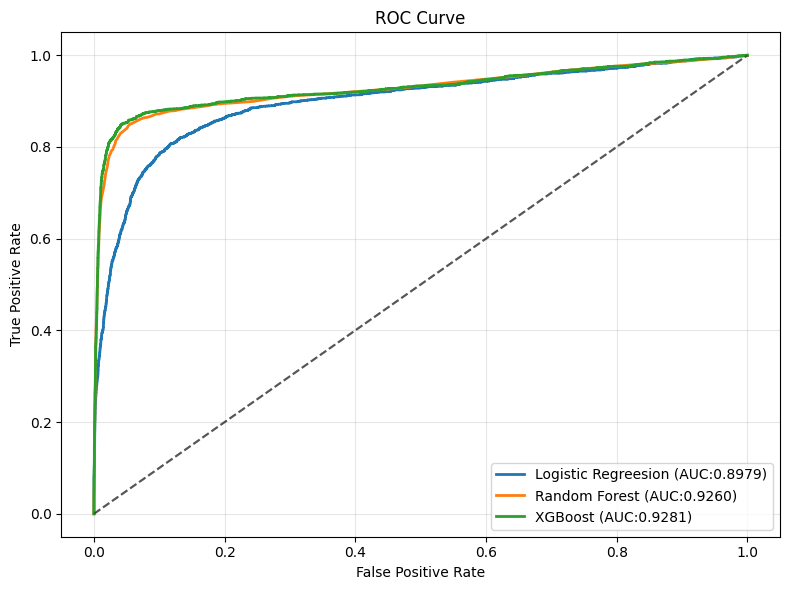

In [12]:
# === ROC CURVE ===
plt.figure(figsize=(8,6))
for name,_,proba in model_list:
    fpr,tpr,_=roc_curve(y_test,proba)
    auc = roc_auc_score(y_test,proba)
    plt.plot(fpr,tpr,label=f"{name} (AUC:{auc:.4f})",linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

customer_support_satisfaction    0.007066
age                              0.008272
num_notification_opt_out         0.008505
usage_trend_3m_6m                0.008605
usage_minutes_3m                 0.012807
app_rating                       0.017392
monthly_charges                  0.035840
support_tickets_30d              0.036502
satisfaction_score               0.043061
payment_delay_days               0.054033
subscription_type_enc            0.058922
avg_daily_usage_minutes          0.068393
usage_minutes_12m                0.075817
has_active_promo_enc             0.078086
account_tenure_months            0.120994
monthly_active_days              0.141604
avg_active_days_3m               0.224102
dtype: float32


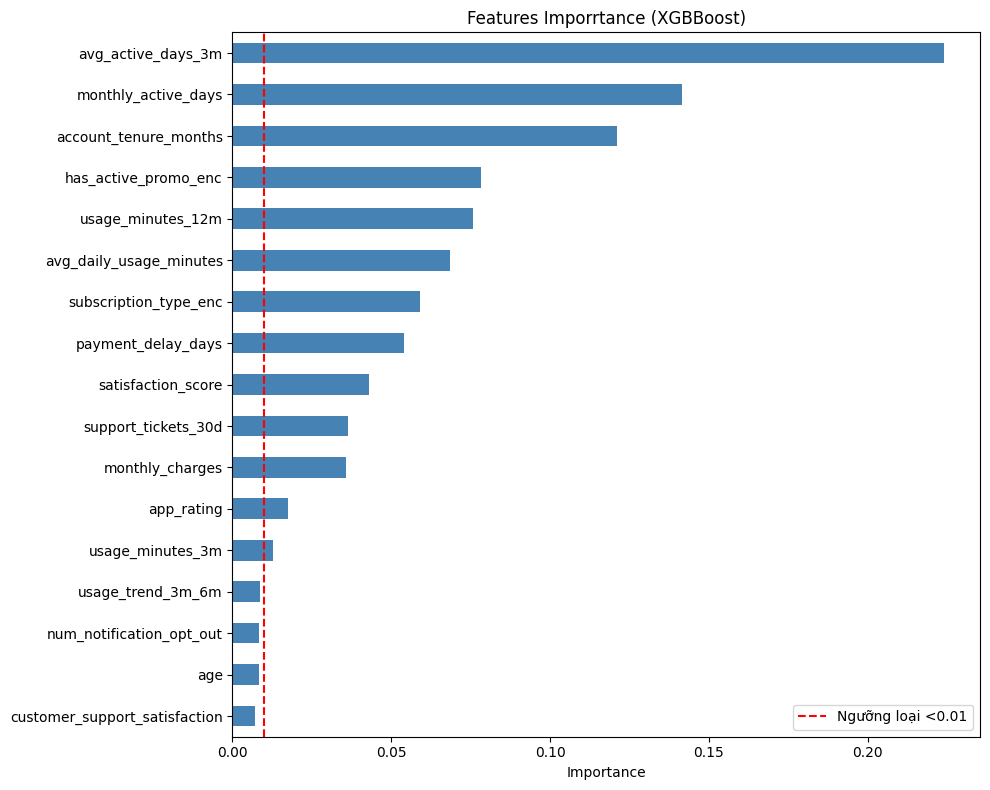

⚠️ 4 features importance < 0.01 → sẽ loại ở Bước 11


In [13]:
# === FEATURE IMPORTANCE (Random Forest) ===
feat_imp=pd.Series(xgb.feature_importances_,index=X.columns)
feat_imp= feat_imp.sort_values(ascending=True)

print(feat_imp)

plt.figure(figsize=(10,8))
feat_imp.plot(kind='barh',color='steelblue')
plt.title(f"Features Imporrtance (XGBBoost)")
plt.xlabel('Importance')
plt.axvline(x=0.01, color='red',linestyle='--',label='Ngưỡng loại <0.01')
plt.legend()
plt.tight_layout()
plt.show()
low_imp = feat_imp[feat_imp < 0.01]
print(f"⚠️ {len(low_imp)} features importance < 0.01 → sẽ loại ở Bước 11")

---
# Bước 11: Feature Reduction ✂️

Loại features **importance ≈ 0** → retrain xem kết quả.

In [14]:
imp_threshold=0.01
important_features=feat_imp[feat_imp>=imp_threshold].index.tolist()
#print(keep_features)

X_train_red=X_train[important_features]
X_test_red=X_test[important_features]

print(f"Features trước: {X_train.shape[1]}")
print(f"Features sau  : {X_train_red.shape[1]}")
print(f"Đã loại: {X_train.shape[1] - X_train_red.shape[1]} features")

#Retrain với ít features <0.01
xgb_reduced=XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                          random_state=RANDOM_STATE,eval_metric='logloss')  #eval_metric='logloss':
xgb_reduced.fit(X_train_red,y_train)
xgb_reduced_pred=xgb_reduced.predict(X_test_red)
xgb_reduced_proba=xgb_reduced.predict_proba(X_test_red)[:,1]

print(f"\n📊 XGBoost (sau Feature Reduction)")
print(f"  Accuracy : {accuracy_score(y_test, xgb_reduced_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, xgb_reduced_proba):.4f}")
print(f"  Recall   : {recall_score(y_test, xgb_reduced_pred, pos_label=0):.4f}")
print(f"  F1-Score : {f1_score(y_test, xgb_reduced_pred, pos_label=0):.4f}")
print(f"\n👉 Ít features hơn + kết quả tương đương/tốt hơn = model đơn giản hơn = THẮNG!")


Features trước: 17
Features sau  : 13
Đã loại: 4 features

📊 XGBoost (sau Feature Reduction)
  Accuracy : 0.9345
  AUC-ROC  : 0.9271
  Recall   : 0.9772
  F1-Score : 0.9576

👉 Ít features hơn + kết quả tương đương/tốt hơn = model đơn giản hơn = THẮNG!


---
# Bước 12: Tinh chỉnh — Hyperparameter Tuning 🎛️

Dùng **GridSearchCV** để tìm tham số tốt nhất cho model tốt nhất.

> 💡 GridSearchCV = thử TẤT CẢ tổ hợp tham số + đánh giá bằng Cross-Validation

In [15]:
# === GRIDSEARCHCV cho Random XGBoost ===

param_grid = {
    'n_estimators': [50, 100, 200],         # Số cây
    'learning_rate': [0.01,0.1,0.2],        # Tốc độ học (co hẹp khoảng cách sửa sai)
    'max_depth': [3, 5, 10, None],          # Độ sâu cây, chống học vẹt
    'min_samples_split': [2, 5, 10],        # Số mẫu tối thiểu để chia nhánh
}

grid_search=GridSearchCV(
    estimator=XGBClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE),
    scoring='roc_auc',                   #Tối ưu AUC
    n_jobs=-1,                           # Dùng tất cả CPU
    verbose=0                           #Chạy ngầm, khoongcaanf in ra màn hình
)

grid_search.fit(X_train_red,y_train)

print("✅ GridSearchCV hoàn thành!")
print(f"\n🏆 Best params:")
for param,value in grid_search.best_params_.items():
    print(f" *{param}: {value}")
print(f"\n📊 Best AUC-ROC (CV): {grid_search.best_score_:.4f}")


✅ GridSearchCV hoàn thành!

🏆 Best params:
 *learning_rate: 0.2
 *max_depth: 3
 *min_samples_split: 2
 *n_estimators: 200

📊 Best AUC-ROC (CV): 0.9262


---
# Bước 13: Retrain với Best Params 🔄

In [16]:
# === RETRAIN VỚI BEST PARAMS ===
best_model=grid_search.best_estimator_ 

best_pred=best_model.predict(X_test_red)
best_proba=best_model.predict_proba(X_test_red)[:,1]

print("📊 RANDOM FOREST (sau GridSearchCV)")
print(f"  Accuracy : {accuracy_score(y_test, best_pred):.4f}")
print(f"  AUC-ROC  : {roc_auc_score(y_test, best_proba):.4f}")
print(f"  Recall   : {recall_score(y_test, best_pred, pos_label=1):.4f}")
print(f"  Precision: {precision_score(y_test, best_pred, pos_label=1):.4f}")
print(f"  F1-Score : {f1_score(y_test, best_pred, pos_label=1):.4f}")


📊 RANDOM FOREST (sau GridSearchCV)
  Accuracy : 0.9346
  AUC-ROC  : 0.9276
  Recall   : 0.7966
  Precision: 0.9230
  F1-Score : 0.8552


In [17]:
print(pd.Series(best_pred).value_counts())

0    7908
1    2092
Name: count, dtype: int64


In [18]:
# === KIỂM TRA KPI ===
kpi_auc=0.9
kpi_recall=0.85 

actual_auc=roc_auc_score(y_test,best_proba)
actual_recall=recall_score(y_test,best_pred,pos_label=0)

print("=" * 50)
print("🎯 KIỂM TRA KPI")
print("=" * 50)
print(f"  AUC-ROC: {actual_auc:.4f}  {'✅ ĐẠT' if actual_auc >= kpi_auc else '❌ CHƯA ĐẠT'}  (KPI ≥ {kpi_auc})")
print(f"  Recall : {actual_recall:.4f}  {'✅ ĐẠT' if actual_recall >= kpi_recall else '❌ CHƯA ĐẠT'}  (KPI ≥ {kpi_recall})")


if actual_auc >= kpi_auc and actual_recall >= kpi_recall:
    print("\n🎉 TẤT CẢ KPI ĐẠT → Sang bước 15")
else:
    print("\n🔄 CHƯA ĐẠT → Cần: thử model khác, thêm features, hoặc điều chỉnh threshold")
    print("   (Bước 15 sẽ giúp cải thiện Recall bằng cách thay đổi ngưỡng)")


🎯 KIỂM TRA KPI
  AUC-ROC: 0.9276  ✅ ĐẠT  (KPI ≥ 0.9)
  Recall : 0.9787  ✅ ĐẠT  (KPI ≥ 0.85)

🎉 TẤT CẢ KPI ĐẠT → Sang bước 15


---
# Bước 15: Cutoff Threshold — Ngưỡng xác suất 🎚️

- Bối cảnh chọn ngưỡng: Để thực hiện gọi và chắm sóc khách hàng thì cần rất nhiều nguồn lực, cũng như budget để chăm sóc (voucher 50k, giảm giá, tặng quà,..). Vì ngân sách công ty có hạn, kèm thêm nhân sự CSKH cũng không nhiều (mỗi ngày chỉ gọi được khoảng 50 cuộc) nên muốn chọn ra chính 

- Nâng ngưỡng lên 0.7 : Giúp nâng tỷ lệ đoán chính xác khách sẽ churn lên, tập trung nguồn lực và buget khuyến mãi cho những người có tỷ lệ Churn (rời bỏ cao) => Giảm bớt cuộc gọi không cần thiết hoặc những cuộc gọi làm phiền những khách hàng đang sử dụng app binh thường

In [19]:
# === PHÂN TÍCH THRESHOLD ===
thresholds = np.arange(0.1, 0.95, 0.05)

th_results=[]
for th in thresholds:
    pred_th=(best_proba >= th).astype(int)
    th_results.append({
        'Threshold': th,
        'Recall_churn': recall_score(y_test, pred_th, pos_label=1),
        'Precision_churn': precision_score(y_test, pred_th, pos_label=1, zero_division=0),
        'F1_churn': f1_score(y_test, pred_th, pos_label=1, zero_division=0),
        'Accuracy': accuracy_score(y_test, pred_th)
    })
    
th_df = pd.DataFrame(th_results)
print(th_df)

    Threshold  Recall_churn  Precision_churn  F1_churn  Accuracy
0        0.10      0.896040         0.591181  0.712365    0.8246
1        0.15      0.887376         0.671768  0.764664    0.8676
2        0.20      0.880776         0.731916  0.799476    0.8929
3        0.25      0.876238         0.778022  0.824214    0.9094
4        0.30      0.867162         0.813782  0.839625    0.9197
5        0.35      0.853960         0.848361  0.851151    0.9276
6        0.40      0.834983         0.882686  0.858173    0.9331
7        0.45      0.822607         0.905129  0.861898    0.9361
8        0.50      0.796617         0.923040  0.855182    0.9346
9        0.55      0.770627         0.938222  0.846206    0.9321
10       0.60      0.742162         0.951852  0.834029    0.9284
11       0.65      0.711221         0.959911  0.817062    0.9228
12       0.70      0.672030         0.961629  0.791161    0.9140
13       0.75      0.629125         0.962753  0.760978    0.9042
14       0.80      0.5866

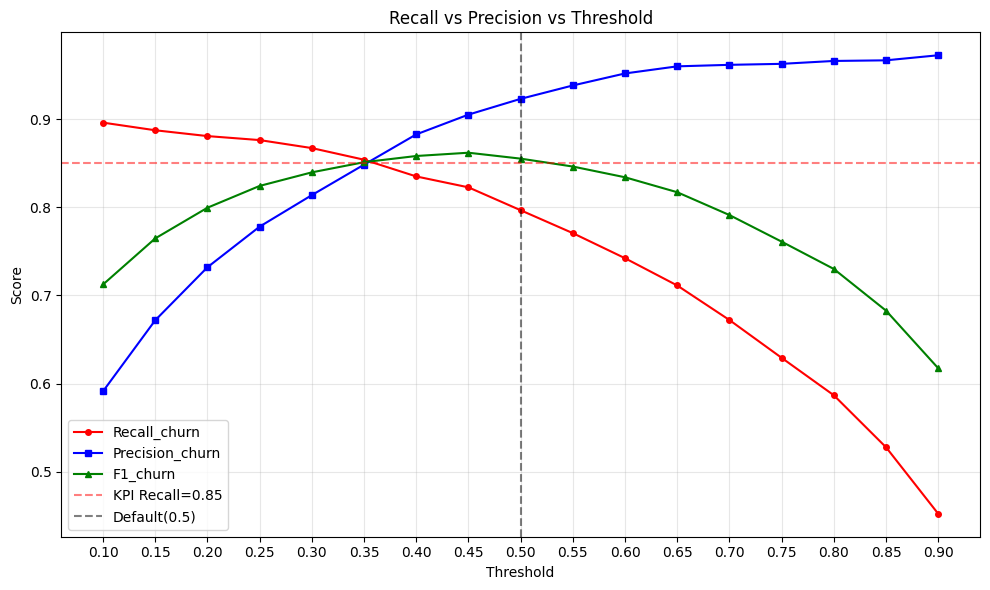

In [20]:
# VẼ biểu đồ
plt.figure(figsize=(10,6))
plt.plot(th_df['Threshold'],th_df['Recall_churn'],'r-o', label='Recall_churn',markersize=4)
plt.plot(th_df['Threshold'],th_df['Precision_churn'],'b-s', label='Precision_churn',markersize=4)
plt.plot(th_df['Threshold'],th_df['F1_churn'],'g-^', label='F1_churn',markersize=4)
plt.axhline(y=kpi_recall,color='red',linestyle='--',alpha=0.5,label=f'KPI Recall={kpi_recall}')
plt.axvline(x=0.5,color='black',linestyle='--',alpha=0.5,label="Default(0.5)")

plt.xticks(np.arange(0.1,0.95,0.05))
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Recall vs Precision vs Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [21]:
# === TÌM THRESHOLD TỐI ƯU ===
# Tìm threshold cao nhất mà vẫn đạt Recall ≥ KPI
valid = th_df[th_df['Recall_churn'] >= kpi_recall]

print(valid)
if len(valid) > 0:
    best_th = valid.loc[valid['F1_churn'].idxmax()]
    optimal_threshold = best_th['Threshold']
else:
    # Nếu không đạt, lấy threshold có Recall cao nhất
    best_th = th_df.loc[th_df['Recall_churn'].idxmax()]
    optimal_threshold = best_th['Threshold']

print(f"🎚️ NGƯỠNG TỐI ƯU: {optimal_threshold:.2f}")
print(f"   Recall    : {best_th['Recall_churn']:.4f}")
print(f"   Precision : {best_th['Precision_churn']:.4f}")
print(f"   F1        : {best_th['F1_churn']:.4f}")
print(f"   Accuracy  : {best_th['Accuracy']:.4f}")

   Threshold  Recall_churn  Precision_churn  F1_churn  Accuracy
0       0.10      0.896040         0.591181  0.712365    0.8246
1       0.15      0.887376         0.671768  0.764664    0.8676
2       0.20      0.880776         0.731916  0.799476    0.8929
3       0.25      0.876238         0.778022  0.824214    0.9094
4       0.30      0.867162         0.813782  0.839625    0.9197
5       0.35      0.853960         0.848361  0.851151    0.9276
🎚️ NGƯỠNG TỐI ƯU: 0.35
   Recall    : 0.8540
   Precision : 0.8484
   F1        : 0.8512
   Accuracy  : 0.9276


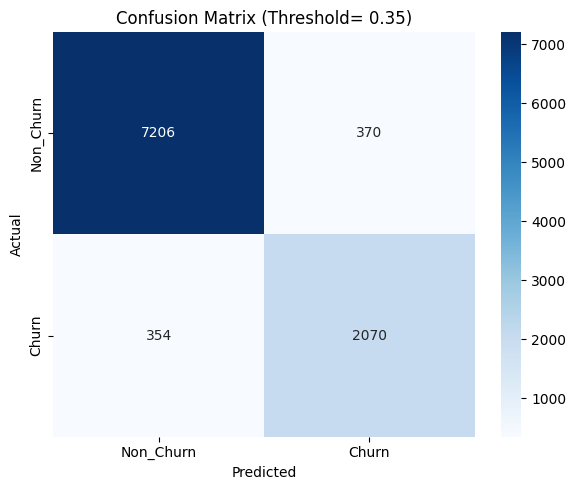

  ✅ True Negative  (Mô hình đoán ĐÚNG khách Ở LẠI)      : 7206
  ✅ True Positive  (Mô hình bắt ĐÚNG khách BỎ APP)     : 2070 ◄── (Mục tiêu chính)
  ❌ False Positive (Mô hình đoán NHẦM Ở lại thành Bỏ)  : 370 ◄── (Lãng phí voucher)
  ❌ False Negative (Mô hình BỎ SÓT khách thực tế Bỏ)   : 354 ◄── (Nguy hiểm!)


In [22]:
# === KẾT QUẢ CUỐI CÙNG: CONFUSION MATRIX VỚI OPTIMAL THRESHOLD ===
final_pred=(best_proba>=optimal_threshold).astype(int)
#print(final_pred)

cm=confusion_matrix(y_test,final_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Non_Churn','Churn'],
            yticklabels=['Non_Churn','Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f"Confusion Matrix (Threshold= {optimal_threshold:.2f})")
plt.tight_layout()
plt.show()


print(f"  ✅ True Negative  (Mô hình đoán ĐÚNG khách Ở LẠI)      : {cm[0][0]}")
print(f"  ✅ True Positive  (Mô hình bắt ĐÚNG khách BỎ APP)     : {cm[1][1]} ◄── (Mục tiêu chính)")
print(f"  ❌ False Positive (Mô hình đoán NHẦM Ở lại thành Bỏ)  : {cm[0][1]} ◄── (Lãng phí voucher)")
print(f"  ❌ False Negative (Mô hình BỎ SÓT khách thực tế Bỏ)   : {cm[1][0]} ◄── (Nguy hiểm!)")





In [23]:
from pathlib import Path
import joblib

models_dir = Path('/Users/thanhnhat/Documents/mockprojectvti/models')
models_dir.mkdir(parents=True, exist_ok=True)

artifact_path = models_dir / 'best_model.joblib'
joblib.dump(
    {
        'model': best_model,
        'threshold': float(optimal_threshold) if 'optimal_threshold' in globals() else None,
        'feature_columns': X_train_red.columns.tolist() if 'X_train_red' in globals() else None,
    },
    artifact_path,
)

print(f'Saved best model to: {artifact_path}')

Saved best model to: /Users/thanhnhat/Documents/mockprojectvti/models/best_model.joblib
